In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os

In [14]:
def bland_altman_plot(data1, data2, cohort, title, fig_scaler=8, *args, **kwargs):
    data1 = np.asarray(data1)
    data2 = np.asarray(data2)
    n_samples = len(data1)

    mean = np.mean([data1, data2], axis=0)
    diff = data1 - data2
    md   = np.mean(diff)
    sd   = np.std(diff, axis=0)

    plt.figure(figsize=(fig_scaler, fig_scaler * 5 / 8))

    palette = sns.color_palette("bright", len(cohort.unique()))
    sns.scatterplot(x=mean, y=diff, hue=cohort, palette=palette, *args, **kwargs)

    plt.axhline(md,           color='gray', linestyle='--')
    plt.axhline(md + 1.96*sd, color='gray', linestyle='--')
    plt.axhline(md - 1.96*sd, color='gray', linestyle='--')
    plt.title(title, fontsize = 20)
    plt.xlabel(r"(mocap + mobgap)/2", fontsize = 16)
    plt.ylabel("mocap - mobgap", fontsize = 16)
    plt.legend(bbox_to_anchor=(1.05, 1), prop = { "size": 16 }, loc='upper left')

    plt.tight_layout()
    plt.show()

def errors(mobgap_wb_dmo, mocap_wb_dmo):
    absolute_error = []
    relative_error = []
    for SS, RS in zip(mobgap_wb_dmo, mocap_wb_dmo):
        absolute_error.append(abs(SS-RS))
        relative_error = abs((SS-RS)/RS)*100
    mae = np.nanmean(absolute_error)
    upper_loa = mae + 1.96*np.nanstd(absolute_error)
    lower_loa = mae - 1.96*np.nanstd(absolute_error)
    return absolute_error, relative_error, mae, upper_loa, lower_loa

def calc_metrics(cur_metrics_ser, cur_subgroup_metrics):
    cur_metrics_ser["Accuracy"] = (cur_subgroup_metrics["wb_TPs"].sum() + cur_subgroup_metrics["wb_TNs"].sum())/(cur_subgroup_metrics["wb_TPs"].sum() + cur_subgroup_metrics["wb_TNs"].sum() + cur_sub_metrics["wb_FPs"].sum() + cur_subgroup_metrics["wb_FNs"].sum())
    cur_metrics_ser["Sensitivity"] = (cur_subgroup_metrics["wb_TPs"].sum())/(cur_subgroup_metrics["wb_TPs"].sum() + cur_subgroup_metrics["wb_FNs"].sum())
    cur_metrics_ser["Positive Predictive Value"] = (cur_subgroup_metrics["wb_TPs"].sum())/(cur_subgroup_metrics["wb_TPs"].sum() + cur_subgroup_metrics["wb_FPs"].sum())
    cur_metrics_ser["Specificity"] = (cur_subgroup_metrics["wb_TNs"].sum())/(cur_subgroup_metrics["wb_TNs"].sum() + cur_subgroup_metrics["wb_FPs"].sum())
    cur_metrics_ser["F1 Score"] = (2*cur_metrics_ser["Positive Predictive Value"]*cur_metrics_ser["Sensitivity"])/(cur_metrics_ser["Positive Predictive Value"]+cur_metrics_ser["Sensitivity"])
    return cur_metrics_ser

,Unnamed: 0,cohort,subject,file_name,wb_ID,wb_TPs,wb_FPs,wb_FNs,wb_TNs,mobgap_ICs,...,cadence_mobgap,walking_speed_mocap,walking_speed_mobgap,IC_Sensitivity,IC_Positive_Predictive_Value,IC_F1_Score,wb_Accuracy,wb_Sensitivity,wb_Specificity,wb_Positive_Predictive_Value
0,0,CP,855,standing.tsv,NaN,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN
1,1,CP,855,10m_walk.tsv,1.0,1,0,0,0,20,...,100.606224,0.849332,1.028363,0.947368,0.900000,0.923077,1.0,1.0,NaN,1.0
2,2,CP,855,10m_walk_bag.tsv,1.0,1,0,0,0,20,...,98.339018,0.755995,1.014112,0.950000,0.950000,0.950000,1.0,1.0,NaN,1.0
3,3,CP,855,10m_walk_utensils.tsv,1.0,1,0,0,0,26,...,100.485088,0.770474,0.943743,1.000000,0.923077,0.960000,1.0,1.0,NaN,1.0
4,4,CP,855,10m_walk_utensils.tsv,2.0,1,0,0,0,28,...,92.674436,NaN,0.792154,0.794118,0.964286,0.870968,1.0,1.0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,101,PSP,836,10m_walk_step.tsv,1.0,1,0,0,0,23,...,89.360458,0.638022,0.588794,0.956522,0.956522,0.956522,1.0,1.0,NaN,1.0
102,102,PSP,836,tug.tsv,1.0,1,0,0,0,20,...,81.460752,0.452019,0.481244,0.947368,0.900000,0.923077,1.0,1.0,NaN,1.0
103,103,PSP,836,TCW.tsv,1.0,1,0,0,0,74,...,96.034003,NaN,0.599053,0.973333,0.986486,0.979866,1.0,1.0,NaN,1.0
104,104,PSP,836,TCCW.tsv,1.0,1,0,0,0,72,...,94.429212,0.646720,0.600158,0.972973,1.000000,0.986301,1.0,1.0,NaN,1.0


,Subject,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score
0,855,CP,1.0,1.0,1.0,1.0,1.0
0,718,CP,1.0,1.0,1.0,1.0,1.0
0,234,CP,0.888889,0.875,1.0,1.0,0.933333
0,884,CP,0.888889,0.875,1.0,1.0,0.933333
0,383,CP,1.0,1.0,1.0,1.0,1.0
0,582,CP,1.0,1.0,1.0,1.0,1.0
0,875,CP,0.888889,0.875,1.0,1.0,0.933333
0,864,PSP,0.9,0.888889,1.0,1.0,0.941176
0,899,PSP,0.9,1.0,0.5,0.888889,0.941176
0,126,PSP,0.888889,0.875,1.0,1.0,0.933333


,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score
0,CP,0.955224,0.95,1.0,1.0,0.974359
0,PSP,0.947368,0.941176,0.8,0.969697,0.955224


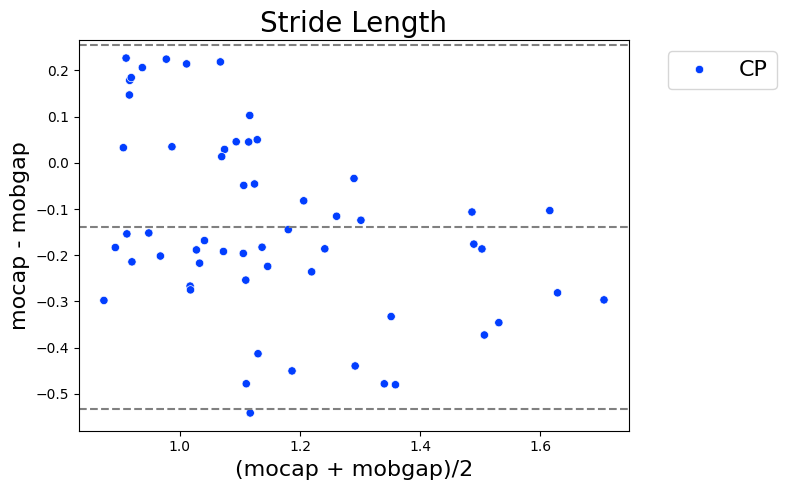

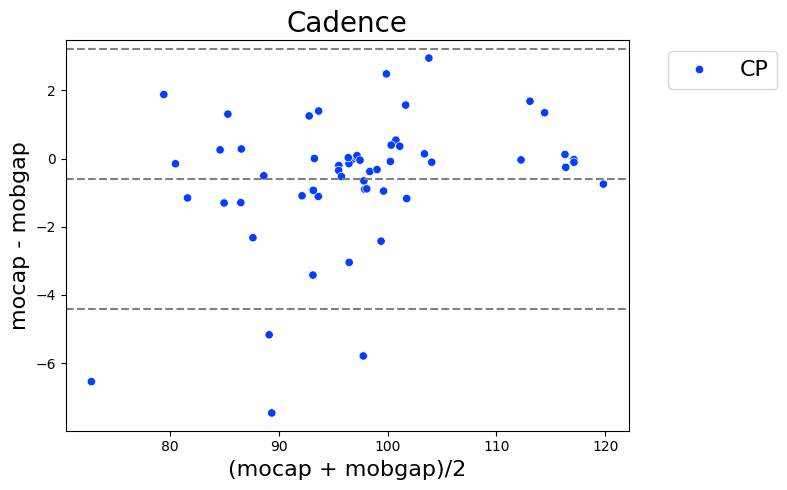

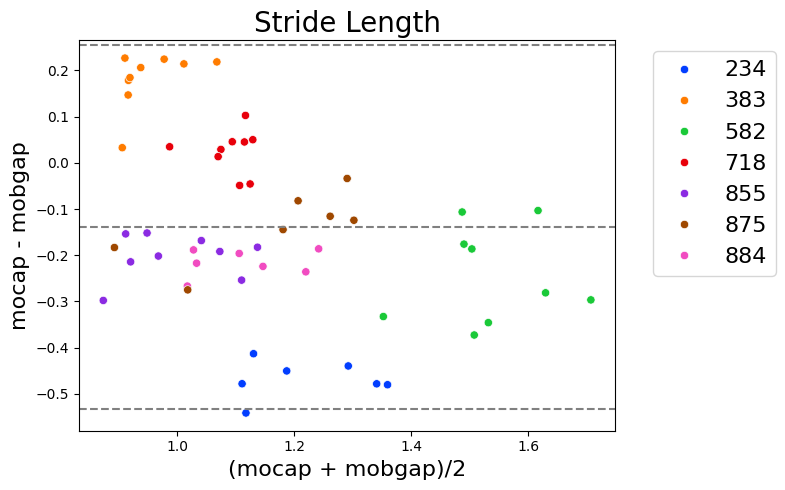

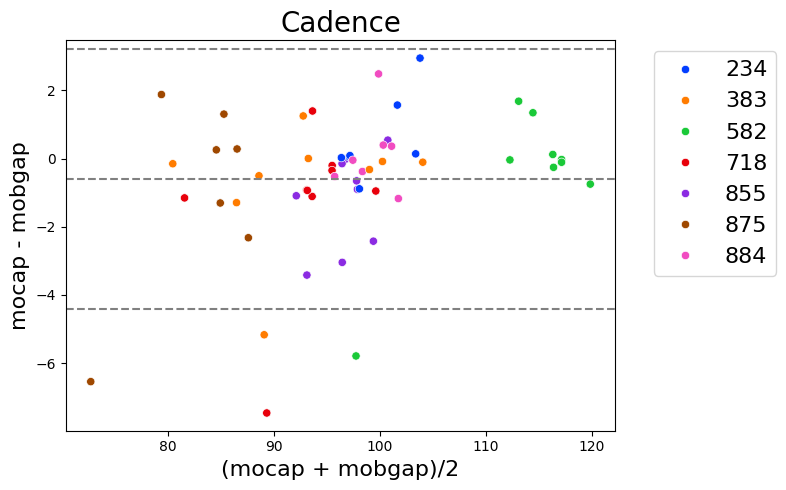

In [15]:
all_metrics = pd.read_csv("In-Lab Parameters/default_pipeline_output.csv")

all_metrics = all_metrics[all_metrics["cohort"] != "HA"] # drop HA

subjects = all_metrics["subject"].unique()

# wb-level stats stats
# calculate IC results into metrics dataframe
mask = all_metrics["IC_TPs"] > 0  # only keep rows where wb_ID is not NaN
all_metrics.loc[mask, "IC_Sensitivity"] = (
    all_metrics.loc[mask, "IC_TPs"] /
    (all_metrics.loc[mask, "IC_TPs"] + all_metrics.loc[mask, "IC_FNs"])
)
all_metrics.loc[mask, "IC_Positive_Predictive_Value"] = (
    all_metrics.loc[mask, "IC_TPs"] /
    (all_metrics.loc[mask, "IC_TPs"] + all_metrics.loc[mask, "IC_FPs"])
)
all_metrics.loc[mask, "IC_F1_Score"] = (
    (2*all_metrics.loc[mask, "IC_Sensitivity"]*all_metrics.loc[mask, "IC_Positive_Predictive_Value"]) /
    (all_metrics.loc[mask, "IC_Sensitivity"]+all_metrics.loc[mask, "IC_Positive_Predictive_Value"])
)

# same for wb
all_metrics["wb_Accuracy"] = (
    (all_metrics["wb_TPs"] + all_metrics["wb_TNs"]) /
    (all_metrics["wb_TPs"] + all_metrics["wb_FPs"] + all_metrics["wb_FNs"] + all_metrics["wb_TNs"])
)
all_metrics["wb_Sensitivity"] = (
    all_metrics["wb_TPs"] /
    (all_metrics["wb_TPs"] + all_metrics["wb_FNs"])
)
all_metrics["wb_Specificity"] = (
    all_metrics["wb_TNs"] /
    (all_metrics["wb_TNs"]+all_metrics["wb_FPs"])
)
all_metrics["wb_Positive_Predictive_Value"] = (
    all_metrics["wb_TPs"] /
    (all_metrics["wb_TPs"] + all_metrics["wb_FPs"])
)

# subject-level stats
subject_metrics = pd.DataFrame(columns = ["Subject", "Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"])
for subject in subjects:
    cur_sub_metrics = all_metrics[all_metrics["subject"] == subject]
    subject_metrics_ser = pd.Series(index=["Subject", "Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"], dtype=object)
    subject_metrics_ser["Subject"] = subject
    subject_metrics_ser["Cohort"] = cur_sub_metrics["cohort"].iloc[0]
    subject_metrics_ser = calc_metrics(subject_metrics_ser, cur_sub_metrics)
    subject_metrics = pd.concat([subject_metrics, subject_metrics_ser.to_frame().T])

# cohort-level stats
cohort_metrics = pd.DataFrame(columns = ["Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"])
cohorts = all_metrics["cohort"].unique()
for cohort in cohorts:
    cur_cohort_metrics = all_metrics[all_metrics["cohort"] == cohort]
    cohort_metrics_ser = pd.Series(index = ["Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"], dtype=object)
    cohort_metrics_ser["Cohort"] = cohort
    cohort_metrics_ser = calc_metrics(cohort_metrics_ser, cur_cohort_metrics)
    cohort_metrics = pd.concat([cohort_metrics, cohort_metrics_ser.to_frame().T])

# display all stats
display(all_metrics)
display(subject_metrics)
display(cohort_metrics)

plot_metrics = all_metrics[all_metrics["cohort"] == "CP"] # change to plot other cohorts

bland_altman_plot(plot_metrics.loc[mask, "stride_length_mocap"], plot_metrics.loc[mask, "stride_length_mobgap"], plot_metrics.loc[mask, "cohort"], "Stride Length")
bland_altman_plot(plot_metrics.loc[mask, "cadence_mocap"], plot_metrics.loc[mask, "cadence_mobgap"], plot_metrics.loc[mask, "cohort"], "Cadence")
bland_altman_plot(plot_metrics.loc[mask, "stride_length_mocap"], plot_metrics.loc[mask, "stride_length_mobgap"], plot_metrics.loc[mask, "subject"], "Stride Length")
bland_altman_plot(plot_metrics.loc[mask, "cadence_mocap"], plot_metrics.loc[mask, "cadence_mobgap"], plot_metrics.loc[mask, "subject"], "Cadence")

In [22]:
cohorts = ["CP", "PSP"]

for cohort in cohorts:
    print_message = "#"*50 + f" {cohort} " + "#"*50
    message_len = len(print_message)
    print("#"*message_len)
    print(print_message)
    print("#"*message_len)
    cohort_metrics = all_metrics[all_metrics["cohort"] == cohort]
    _, _, mae_stride_length, upper_loa_stride_length, lower_loa_stride_length = errors(cohort_metrics["stride_length_mobgap"], cohort_metrics["stride_length_mocap"])
    _, _, mae_cadence, upper_loa_cadence, lower_loa_cadence = errors(cohort_metrics["cadence_mobgap"], cohort_metrics["cadence_mocap"])
    _, _, mae_walking_speed, upper_loa_walking_speed, lower_loa_walking_speed = errors(cohort_metrics["walking_speed_mobgap"], cohort_metrics["walking_speed_mocap"])

    print()
    print(f"Mean wb Accuracy = {cohort_metrics["wb_Accuracy"].mean():.2f} [{cohort_metrics["wb_Accuracy"].mean()-1.96*cohort_metrics["wb_Accuracy"].std():.2f} {cohort_metrics["wb_Accuracy"].mean()+1.96*cohort_metrics["wb_Accuracy"].std():.2f}]")
    print(f"Mean wb Specificity = {cohort_metrics["wb_Specificity"].mean():.2f} [{cohort_metrics["wb_Specificity"].mean()-1.96*cohort_metrics["wb_Specificity"].std():.2f} {cohort_metrics["wb_Specificity"].mean()+1.96*cohort_metrics["wb_Specificity"].std():.2f}]")
    print(f"Mean wb Sensitivity = {cohort_metrics["wb_Sensitivity"].mean():.2f} [{cohort_metrics["wb_Sensitivity"].mean()-1.96*cohort_metrics["wb_Sensitivity"].std():.2f} {cohort_metrics["wb_Sensitivity"].mean()+1.96*cohort_metrics["wb_Sensitivity"].std():.2f}]")
    print(f"Mean wb Positive Predictive Value = {cohort_metrics["wb_Positive_Predictive_Value"].mean():.2f} [{cohort_metrics["wb_Positive_Predictive_Value"].mean()-1.96*cohort_metrics["wb_Positive_Predictive_Value"].std():.2f} {cohort_metrics["wb_Positive_Predictive_Value"].mean()+1.96*cohort_metrics["wb_Positive_Predictive_Value"].std():.2f}]")
    print()
    print(f"Mean IC Sensitivity = {cohort_metrics["IC_Sensitivity"].mean():.2f} [{cohort_metrics["IC_Sensitivity"].mean()-1.96*cohort_metrics["IC_Sensitivity"].std():.2f} {cohort_metrics["IC_Sensitivity"].mean()+1.96*cohort_metrics["IC_Sensitivity"].std():.2f}]")
    print(f"Mean IC Positive Predictive Value = {cohort_metrics["IC_Positive_Predictive_Value"].mean():.2f} [{cohort_metrics["IC_Positive_Predictive_Value"].mean()-1.96*cohort_metrics["IC_Positive_Predictive_Value"].std():.2f} {cohort_metrics["IC_Positive_Predictive_Value"].mean()+1.96*cohort_metrics["IC_Positive_Predictive_Value"].std():.2f}]")
    print(f"Mean IC F1 Score = {cohort_metrics["IC_F1_Score"].mean():.2f} [{cohort_metrics["IC_F1_Score"].mean()-1.96*cohort_metrics["IC_F1_Score"].std():.2f} {cohort_metrics["IC_F1_Score"].mean()+1.96*cohort_metrics["IC_F1_Score"].std():.2f}]")
    print()
    print(f"MAE stride length = {mae_stride_length:.2f} [{lower_loa_stride_length:.2f}, {upper_loa_stride_length:.2f}]")
    print(f"MAE cadence = {mae_cadence:.2f} [{lower_loa_cadence:.2f}, {upper_loa_cadence:.2f}]")
    print(f"MAE walking speed = {mae_walking_speed:.2f} [{lower_loa_walking_speed:.2f}, {upper_loa_walking_speed:.2f}]")
    print()

########################################################################################################
################################################## CP ##################################################
########################################################################################################

Mean wb Accuracy = 0.96 [0.55 1.36]
Mean wb Specificity = 1.00 [1.00 1.00]
Mean wb Sensitivity = 0.95 [0.52 1.38]
Mean wb Positive Predictive Value = 1.00 [1.00 1.00]

Mean IC Sensitivity = 0.97 [0.90 1.05]
Mean IC Positive Predictive Value = 0.92 [0.81 1.03]
Mean IC F1 Score = 0.95 [0.88 1.02]

MAE stride length = 0.21 [-0.05, 0.46]
MAE cadence = 1.24 [-1.93, 4.42]
MAE walking speed = 0.19 [-0.05, 0.43]

#########################################################################################################
################################################## PSP ##################################################
###############################################################

# Analyse Different Algorithms

In [21]:
# get files
files = []
experiment_dir = "In-Lab Parameters\\Pipeline Experiments"
for file in os.listdir(experiment_dir):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        full_file = os.path.join(experiment_dir, filename)

    experiment_metrics = pd.read_csv(full_file)

    mask = experiment_metrics["IC_TPs"] > 0  # only keep rows where wb_ID is not NaN
    experiment_metrics.loc[mask, "IC_Sensitivity"] = (
        experiment_metrics.loc[mask, "IC_TPs"] /
        (experiment_metrics.loc[mask, "IC_TPs"] + experiment_metrics.loc[mask, "IC_FNs"])
    )
    experiment_metrics.loc[mask, "IC_Positive_Predictive_Value"] = (
        experiment_metrics.loc[mask, "IC_TPs"] /
        (experiment_metrics.loc[mask, "IC_TPs"] + experiment_metrics.loc[mask, "IC_FPs"])
    )
    experiment_metrics.loc[mask, "IC_F1_Score"] = (
        (2*experiment_metrics.loc[mask, "IC_Sensitivity"]*experiment_metrics.loc[mask, "IC_Positive_Predictive_Value"]) /
        (experiment_metrics.loc[mask, "IC_Sensitivity"]+experiment_metrics.loc[mask, "IC_Positive_Predictive_Value"])
    )

    # cohort-level stats
    cohort_metrics = pd.DataFrame(columns = ["Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"])
    cohorts = experiment_metrics["cohort"].unique()
    for cohort in cohorts:
        cur_cohort_metrics = experiment_metrics[experiment_metrics["cohort"] == cohort]
        cohort_metrics_ser = pd.Series(index = ["Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"], dtype=object)
        cohort_metrics_ser["Cohort"] = cohort
        cohort_metrics_ser = calc_metrics(cohort_metrics_ser, cur_cohort_metrics)
        cohort_metrics = pd.concat([cohort_metrics, cohort_metrics_ser.to_frame().T])

    cohort_metrics["GSD Algorithm"] = filename.split("_")[0]
    cohort_metrics["IC_Sensitivity"] = cur_cohort_metrics["IC_Sensitivity"].mean()
    cohort_metrics["IC_Positive_Predictive_Value"] = cur_cohort_metrics["IC_Positive_Predictive_Value"].mean()
    cohort_metrics["IC_F1_Score"] = cur_cohort_metrics["IC_F1_Score"].mean()
    cohort_metrics["IC Algorithm"] = filename.split("_")[1].split(".")[0]

    print(filename.split(".")[0])
    display(cohort_metrics)
    print()

GsdAdaptiveIonescu_IcdHKLeeImproved


,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score,GSD Algorithm,IC_Sensitivity,IC_Positive_Predictive_Value,IC_F1_Score,IC Algorithm
0,CP,1.0,1.0,0.384615,0.880597,0.936508,GsdAdaptiveIonescu,0.925765,0.978148,0.948614,IcdHKLeeImproved
0,PSP,0.971429,0.969697,0.166667,0.761905,0.853333,GsdAdaptiveIonescu,0.925765,0.978148,0.948614,IcdHKLeeImproved



GsdAdaptiveIonescu_IcdIonescu


,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score,GSD Algorithm,IC_Sensitivity,IC_Positive_Predictive_Value,IC_F1_Score,IC Algorithm
0,CP,1.0,1.0,0.384615,0.880597,0.936508,GsdAdaptiveIonescu,0.89887,0.98305,0.936486,IcdIonescu
0,PSP,0.971429,0.969697,0.166667,0.761905,0.853333,GsdAdaptiveIonescu,0.89887,0.98305,0.936486,IcdIonescu



GsdAdaptiveIonescu_IcdShinImproved


...

,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score,GSD Algorithm,IC_Sensitivity,IC_Positive_Predictive_Value,IC_F1_Score,IC Algorithm
0,CP,0.955224,0.95,1.0,1.0,0.974359,GsdIonescu,0.993302,0.919103,0.95216,IcdHKLeeImproved
0,PSP,0.947368,0.941176,0.8,0.969697,0.955224,GsdIonescu,0.993302,0.919103,0.95216,IcdHKLeeImproved



GsdIonescu_IcdIonescu


,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score,GSD Algorithm,IC_Sensitivity,IC_Positive_Predictive_Value,IC_F1_Score,IC Algorithm
0,CP,0.955224,0.95,1.0,1.0,0.974359,GsdIonescu,0.972332,0.930003,0.948677,IcdIonescu
0,PSP,0.947368,0.941176,0.8,0.969697,0.955224,GsdIonescu,0.972332,0.930003,0.948677,IcdIonescu



GsdIonescu_IcdShinImproved


,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score,GSD Algorithm,IC_Sensitivity,IC_Positive_Predictive_Value,IC_F1_Score,IC Algorithm
0,CP,0.955224,0.95,1.0,1.0,0.974359,GsdIonescu,0.98431,0.921121,0.949486,IcdShinImproved
0,PSP,0.947368,0.941176,0.8,0.969697,0.955224,GsdIonescu,0.98431,0.921121,0.949486,IcdShinImproved
